# Data Exploration

This notebook explores the original chest X-ray dataset before any cleaning or processing.
The goal is to understand the data, identify potential issues, and make informed decisions
about how to clean and prepare it for training.

## Dataset
- Source: chest X-ray images split into train, test, and val folders
- Classes: NORMAL and PNEUMONIA
- Location: ../datasets/original_datasets/


In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from PIL import Image
from collections import defaultdict


## 1. Dataset Structure

In [ ]:
base_dir = r"C:\Users\Pc\Downloads\xray_pneumonia\datasets\processedData"
OUTPUT_DATA = r"C:\Users\Pc\Downloads\xray_pneumonia\datasets\processedData"
splits = ["train", "test", "val"]
classes = ["NORMAL", "PNEUMONIA"]

for split in splits:
    print(f"\n{split}/")
    for cls in classes:
        path = os.path.join(base_dir, split, cls)
        count = len([f for f in os.listdir(path) if f.lower().endswith(('.jpeg', '.jpg', '.png'))])
        print(f"  {cls}: {count} images")



train/
  NORMAL: 1341 images
  PNEUMONIA: 3875 images

test/
  NORMAL: 234 images
  PNEUMONIA: 390 images

val/
  NORMAL: 8 images
  PNEUMONIA: 8 images


## 2. Class Imbalance

The original dataset is split into 3 folders: train, test, and val.
We examine the class distribution across all folders to understand the overall balance
and decide whether to keep the original split or merge and re-split.


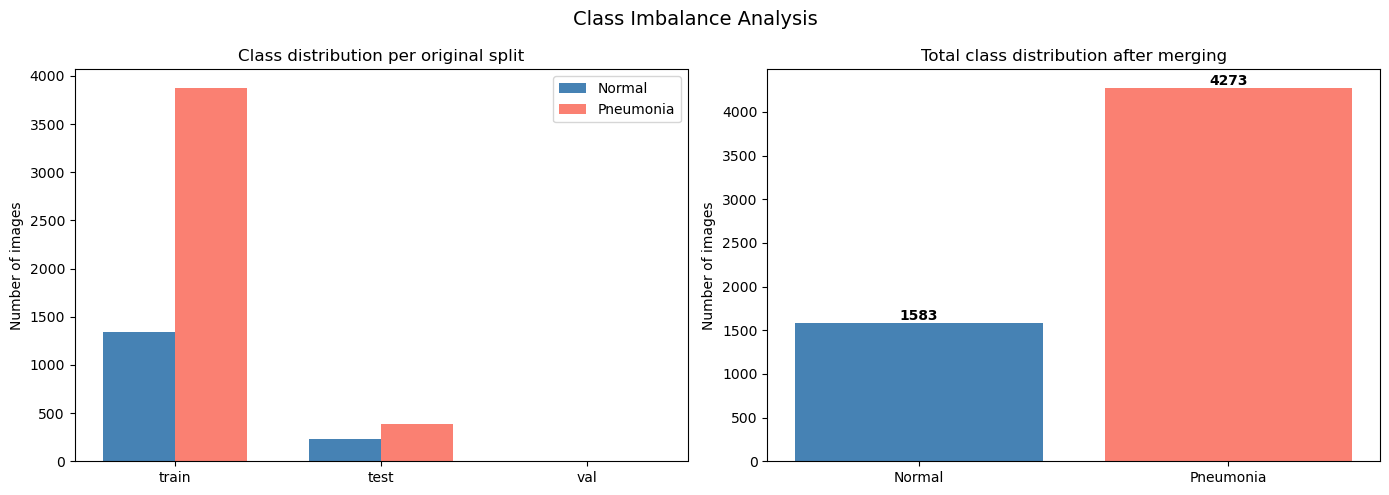

Total Normal: 1583
Total Pneumonia: 4273
Ratio: 1:2


In [8]:
total_normal = 0
total_pneumonia = 0

for split in splits:
    for cls in classes:
        path = os.path.join(base_dir, split, cls)
        count = len([f for f in os.listdir(path) if f.lower().endswith(('.jpeg', '.jpg', '.png'))])
        if cls == "NORMAL":
            total_normal += count
        else:
            total_pneumonia += count

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left chart - original split breakdown
split_normal = []
split_pneumonia = []
for split in splits:
    path_n = os.path.join(base_dir, split, "NORMAL")
    path_p = os.path.join(base_dir, split, "PNEUMONIA")
    split_normal.append(len([f for f in os.listdir(path_n) if f.lower().endswith(('.jpeg', '.jpg', '.png'))]))
    split_pneumonia.append(len([f for f in os.listdir(path_p) if f.lower().endswith(('.jpeg', '.jpg', '.png'))]))

x = np.arange(len(splits))
width = 0.35
axes[0].bar(x - width/2, split_normal, width, label="Normal", color="steelblue")
axes[0].bar(x + width/2, split_pneumonia, width, label="Pneumonia", color="salmon")
axes[0].set_xticks(x)
axes[0].set_xticklabels(splits)
axes[0].set_title("Class distribution per original split")
axes[0].set_ylabel("Number of images")
axes[0].legend()

# Right chart - total after merge
axes[1].bar(["Normal", "Pneumonia"], [total_normal, total_pneumonia], color=["steelblue", "salmon"])
axes[1].set_title("Total class distribution after merging")
axes[1].set_ylabel("Number of images")
for i, v in enumerate([total_normal, total_pneumonia]):
    axes[1].text(i, v + 30, str(v), ha="center", fontweight="bold")

plt.suptitle("Class Imbalance Analysis", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Total Normal: {total_normal}")
print(f"Total Pneumonia: {total_pneumonia}")
print(f"Ratio: 1:{total_pneumonia // total_normal}")


## 3. Image Size Variation

X-ray images come in vastly different sizes. This directly impacts our cleaning decisions
— we need to standardize sizes before training any model.



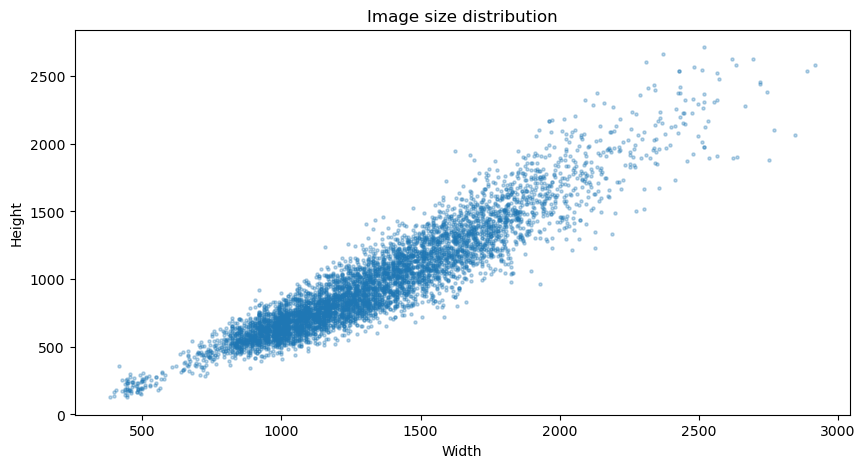

Total images: 5856
Smallest: (384, 127)
Largest: (2916, 2583)
Unique sizes: 4803


In [7]:
sizes = []

for split in splits:
    for cls in classes:
        path = os.path.join(base_dir, split, cls)
        for filename in os.listdir(path):
            if filename.lower().endswith(('.jpeg', '.jpg', '.png')):
                img = Image.open(os.path.join(path, filename))
                sizes.append(img.size)

widths = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

plt.figure(figsize=(10, 5))
plt.scatter(widths, heights, alpha=0.3, s=5)
plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image size distribution")
plt.show()

print(f"Total images: {len(sizes)}")
print(f"Smallest: {min(sizes)}")
print(f"Largest: {max(sizes)}")
print(f"Unique sizes: {len(set(sizes))}")


## 4. Image Mode Distribution

X-rays are naturally grayscale images. However, some images may be saved in RGB format
(3 channels) instead of grayscale (1 channel). This inconsistency needs to be addressed
during cleaning to ensure all images have the same format.


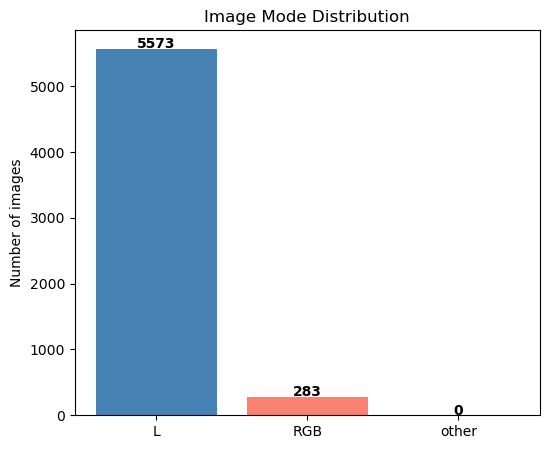

In [9]:
modes = {"L": 0, "RGB": 0, "other": 0}

for split in splits:
    for cls in classes:
        path = os.path.join(base_dir, split, cls)
        for filename in os.listdir(path):
            if filename.lower().endswith(('.jpeg', '.jpg', '.png')):
                img = Image.open(os.path.join(path, filename))
                if img.mode in modes:
                    modes[img.mode] += 1
                else:
                    modes["other"] += 1

plt.figure(figsize=(6, 5))
plt.bar(modes.keys(), modes.values(), color=["steelblue", "salmon", "gray"])
plt.title("Image Mode Distribution")
plt.ylabel("Number of images")
for i, (k, v) in enumerate(modes.items()):
    plt.text(i, v + 10, str(v), ha="center", fontweight="bold")
plt.show()


## 5. Sample Images

Visual inspection of the dataset reveals several important observations:
different lighting conditions, patient positions, zoom levels, and radiological markers.


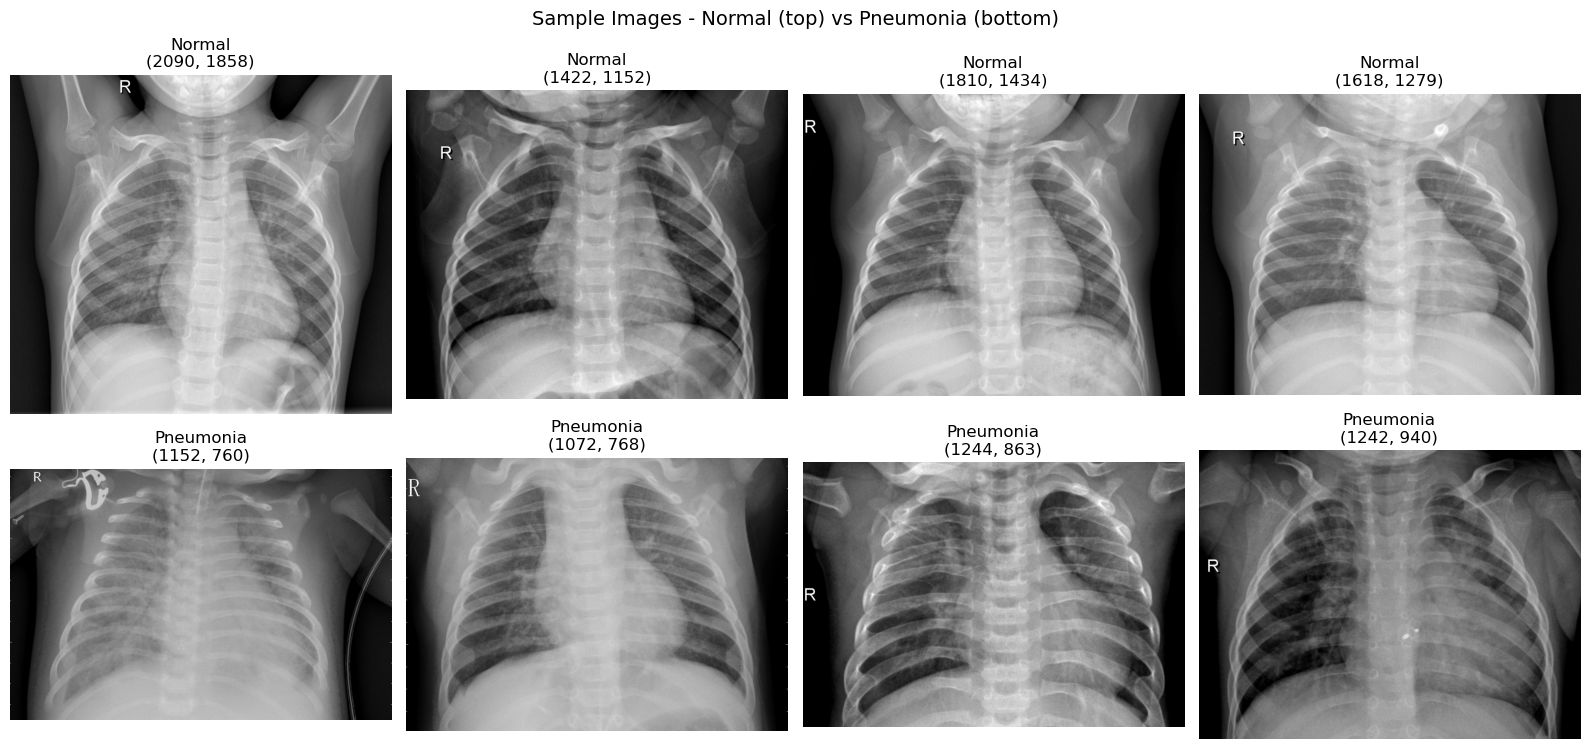

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

normal_path = os.path.join(base_dir, "train", "NORMAL")
pneumonia_path = os.path.join(base_dir, "train", "PNEUMONIA")

normal_images = [f for f in os.listdir(normal_path) if f.lower().endswith(('.jpeg', '.jpg', '.png'))]
pneumonia_images = [f for f in os.listdir(pneumonia_path) if f.lower().endswith(('.jpeg', '.jpg', '.png'))]

for i in range(4):
    img = Image.open(os.path.join(normal_path, normal_images[i]))
    axes[0, i].imshow(img, cmap="gray")
    axes[0, i].set_title(f"Normal\n{img.size}")
    axes[0, i].axis("off")

for i in range(4):
    img = Image.open(os.path.join(pneumonia_path, pneumonia_images[i]))
    axes[1, i].imshow(img, cmap="gray")
    axes[1, i].set_title(f"Pneumonia\n{img.size}")
    axes[1, i].axis("off")

plt.suptitle("Sample Images - Normal (top) vs Pneumonia (bottom)", fontsize=14)
plt.tight_layout()
plt.show()


## 6. Same Patient Duplicates

Some patients have multiple X-rays taken at different angles or times.
If the same patient appears in both train and test sets, the model gets an unfair
advantage — it has seen that patient's lungs before. This is called data leakage.


In [11]:
patient_images = defaultdict(list)

for split in splits:
    for cls in classes:
        path = os.path.join(base_dir, split, cls)
        for filename in os.listdir(path):
            if filename.lower().endswith(('.jpeg', '.jpg', '.png')):
                parts = filename.split("-")
                if len(parts) > 1:
                    patient_id = parts[1]
                    patient_images[patient_id].append((split, cls, filename))

duplicates = {k: v for k, v in patient_images.items() if len(v) > 1}

print(f"Total unique patients: {len(patient_images)}")
print(f"Patients with multiple images: {len(duplicates)}")

# show 3 examples
for patient_id, images in list(duplicates.items())[:3]:
    print(f"\nPatient {patient_id}:")
    for split, cls, filename in images:
        print(f"  {split}/{cls}/{filename}")


Total unique patients: 584
Patients with multiple images: 45

Patient 0429:
  train/NORMAL/IM-0429-0001-0001.jpeg
  train/NORMAL/IM-0429-0001-0002.jpeg
  train/NORMAL/IM-0429-0001.jpeg

Patient 0435:
  train/NORMAL/IM-0435-0001-0001.jpeg
  train/NORMAL/IM-0435-0001.jpeg

Patient 0437:
  train/NORMAL/IM-0437-0001-0001.jpeg
  train/NORMAL/IM-0437-0001-0002.jpeg
  train/NORMAL/IM-0437-0001.jpeg


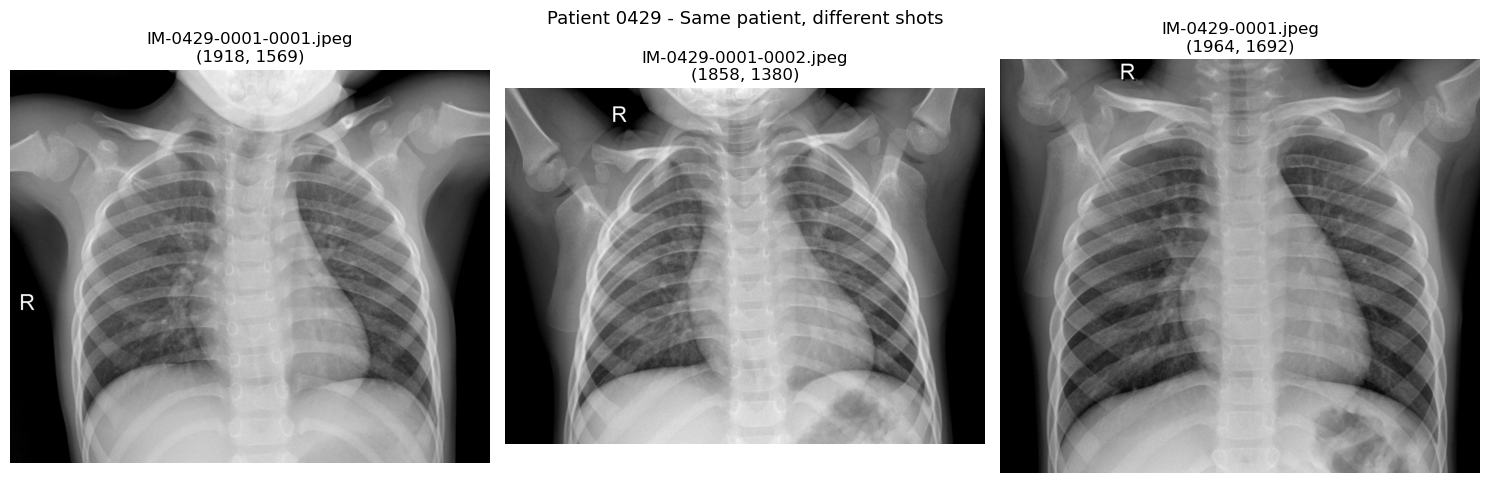

In [12]:
patient_id, images = list(duplicates.items())[0]

fig, axes = plt.subplots(1, len(images), figsize=(5 * len(images), 5))

for i, (split, cls, filename) in enumerate(images):
    path = os.path.join(base_dir, split, cls, filename)
    img = Image.open(path)
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(f"{filename}\n{img.size}")
    axes[i].axis("off")

plt.suptitle(f"Patient {patient_id} - Same patient, different shots", fontsize=13)
plt.tight_layout()
plt.show()


## 7. Corrupted Files

We check if any images cannot be opened or are damaged.
Corrupted files would cause errors during training and must be identified.


In [13]:
corrupted = []

for split in splits:
    for cls in classes:
        path = os.path.join(base_dir, split, cls)
        for filename in os.listdir(path):
            if filename.lower().endswith(('.jpeg', '.jpg', '.png')):
                try:
                    img = Image.open(os.path.join(path, filename))
                    img.verify()
                except Exception as e:
                    corrupted.append((split, cls, filename, str(e)))

print(f"Corrupted images found: {len(corrupted)}")
if corrupted:
    for item in corrupted:
        print(item)


Corrupted images found: 0


## 9. Pixel Statistics

We analyze the pixel intensity of each image to understand brightness and contrast variation
across the dataset. This helps decide whether contrast enhancement is needed during cleaning.


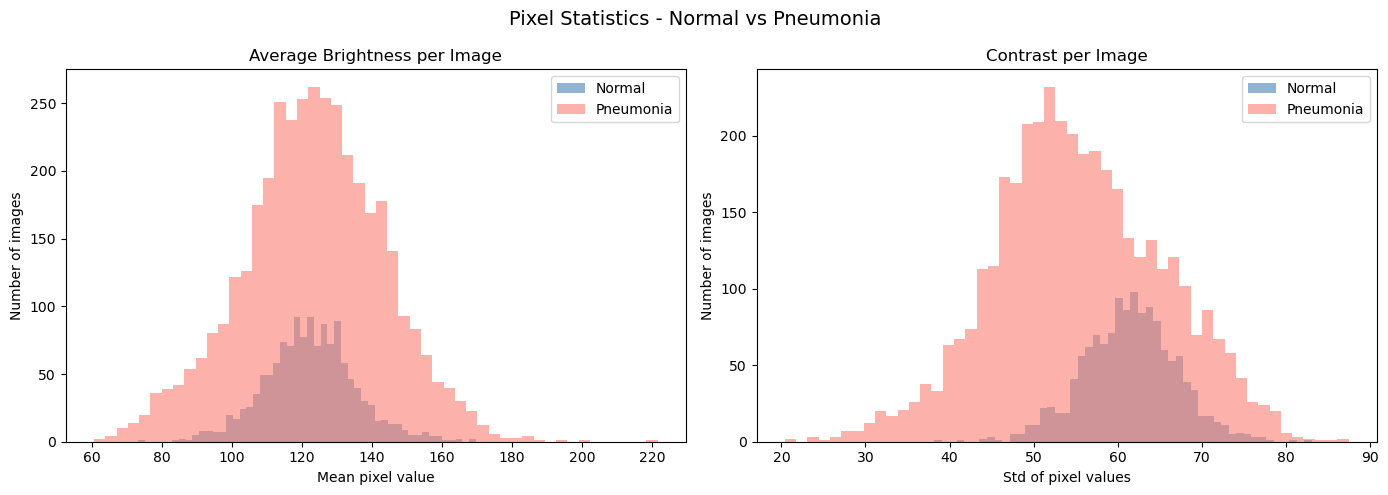

In [15]:
means = {"NORMAL": [], "PNEUMONIA": []}
stds = {"NORMAL": [], "PNEUMONIA": []}

for cls in classes:
    path = os.path.join(base_dir, "train", cls)
    for filename in os.listdir(path):
        if filename.lower().endswith(('.jpeg', '.jpg', '.png')):
            img = np.array(Image.open(os.path.join(path, filename)).convert("L"))
            means[cls].append(img.mean())
            stds[cls].append(img.std())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(means["NORMAL"], bins=50, alpha=0.6, label="Normal", color="steelblue")
axes[0].hist(means["PNEUMONIA"], bins=50, alpha=0.6, label="Pneumonia", color="salmon")
axes[0].set_title("Average Brightness per Image")
axes[0].set_xlabel("Mean pixel value")
axes[0].set_ylabel("Number of images")
axes[0].legend()

axes[1].hist(stds["NORMAL"], bins=50, alpha=0.6, label="Normal", color="steelblue")
axes[1].hist(stds["PNEUMONIA"], bins=50, alpha=0.6, label="Pneumonia", color="salmon")
axes[1].set_title("Contrast per Image")
axes[1].set_xlabel("Std of pixel values")
axes[1].set_ylabel("Number of images")
axes[1].legend()

plt.suptitle("Pixel Statistics - Normal vs Pneumonia", fontsize=14)
plt.tight_layout()
plt.show()


## 10. Average Image per Class

Computing the average of all images per class reveals the typical visual pattern
of normal vs pneumonia X-rays. This shows whether there is a visible difference
between the two classes that a model can learn from.


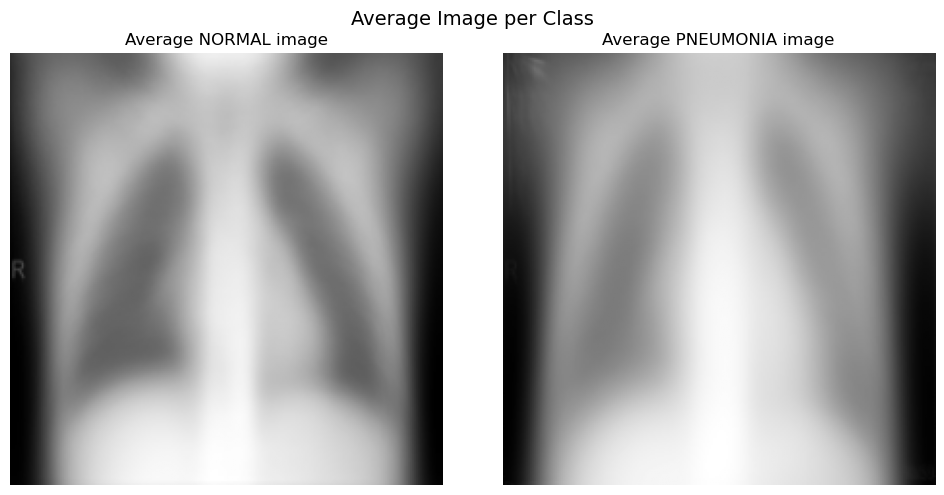

In [16]:
avg_images = {}

for cls in classes:
    path = os.path.join(base_dir, "train", cls)
    images = []
    for filename in os.listdir(path):
        if filename.lower().endswith(('.jpeg', '.jpg', '.png')):
            img = np.array(Image.open(os.path.join(path, filename)).convert("L").resize((224, 224)))
            images.append(img)
    avg_images[cls] = np.mean(images, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, cls in zip(axes, classes):
    ax.imshow(avg_images[cls], cmap="gray")
    ax.set_title(f"Average {cls} image")
    ax.axis("off")

plt.suptitle("Average Image per Class", fontsize=14)
plt.tight_layout()
plt.show()


## 11. Exploration Summary

| Observation | Finding & Problem | Suggested Actions |
|-------------|------------------|----------|
| Dataset split | val only has 16 images — too small to reliably evaluate model performance during training | Merge all folders into one dataset and re-split 70/15/15 to get a meaningful validation set |
| Class imbalance | 1583 normal vs 4273 pneumonia (1:3 ratio) — model will be biased towards predicting pneumonia since it sees 3x more of it | Apply class weights during training to penalize mistakes on the minority class more |
| Image sizes | 912x672 to 2916x2583, almost every image is a different size — models require fixed input size, inconsistent sizes will crash training | Resize all images to 224x224 using padding and resize function to preserve aspect ratio and avoid distorting lung shapes |
| Image mode | 5573 grayscale, 283 RGB — inconsistent channels will cause errors during training | Convert all images to grayscale (L) since X-rays carry no meaningful color information |
| Brightness variation | Pixel intensity distributions vary significantly across images, especially in pneumonia — model sees inconsistent images | Apply contrast normalization during cleaning to standardize image appearance (CLAHE method) |
| Average image | Pneumonia lungs appear visibly brighter and hazier than normal — fluid and infection show as white areas | Confirms the model can learn a real visual signal, not just noise |
| Same patient duplicates | 45 patients have multiple X-rays — if same patient appears in train and test, results are artificially better | Kept as known limitation — 45 out of 5856 images, small impact |
| Corrupted files | 0 found — no action needed | — |
| Zoomed in/out | Clinical variation, not a data error — some X-rays taken closer or further | Left as is — model learns to generalize across zoom levels |
| Different lighting | Varies across images — raw pixel values inconsistent | Handled by normalization during training |
| Patient positions | Hands up, sideways etc. | Left as is — variation helps model generalize |
| R marker | Present on some images — radiological standard marker | Ignored — appears in both classes, not a pneumonia indicator |
